In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [4]:
# Loading the CSV
df = pd.read_csv("/content/Student_performance_data _.csv")

# first few rows
df.head()


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [5]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [6]:
# info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [9]:
df.Gender.value_counts()


,count
Gender,
1,1222
0,1170


In [10]:
# statistics
df.describe()


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


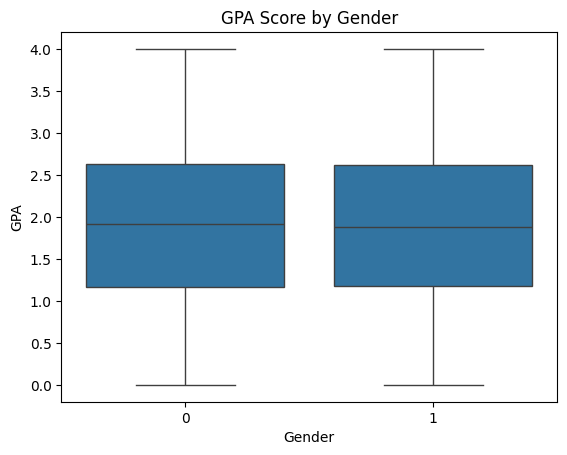

In [11]:
# Example: Boxplot for score by gender
sns.boxplot(x='Gender', y='GPA', data=df)
plt.title("GPA Score by Gender")
plt.show()

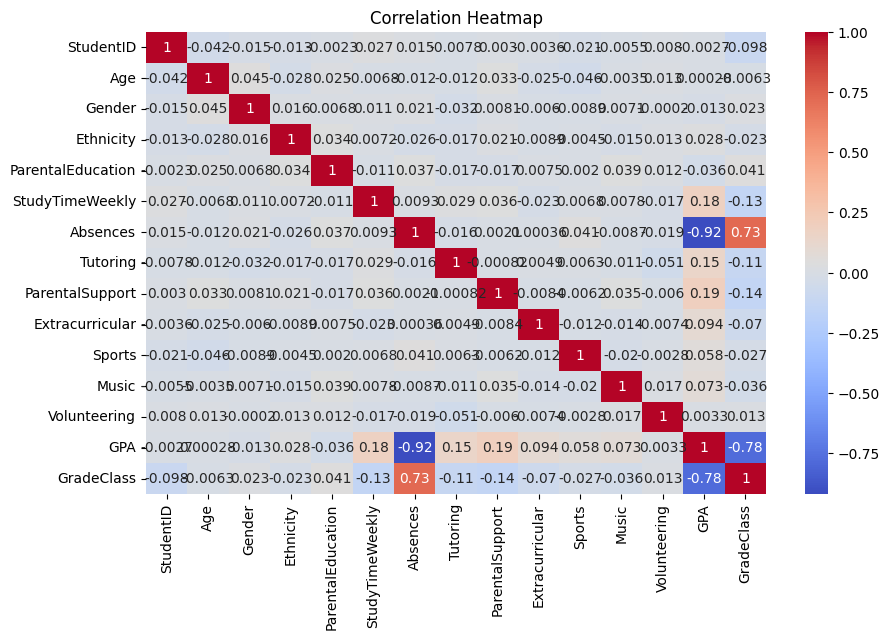

In [12]:
#Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


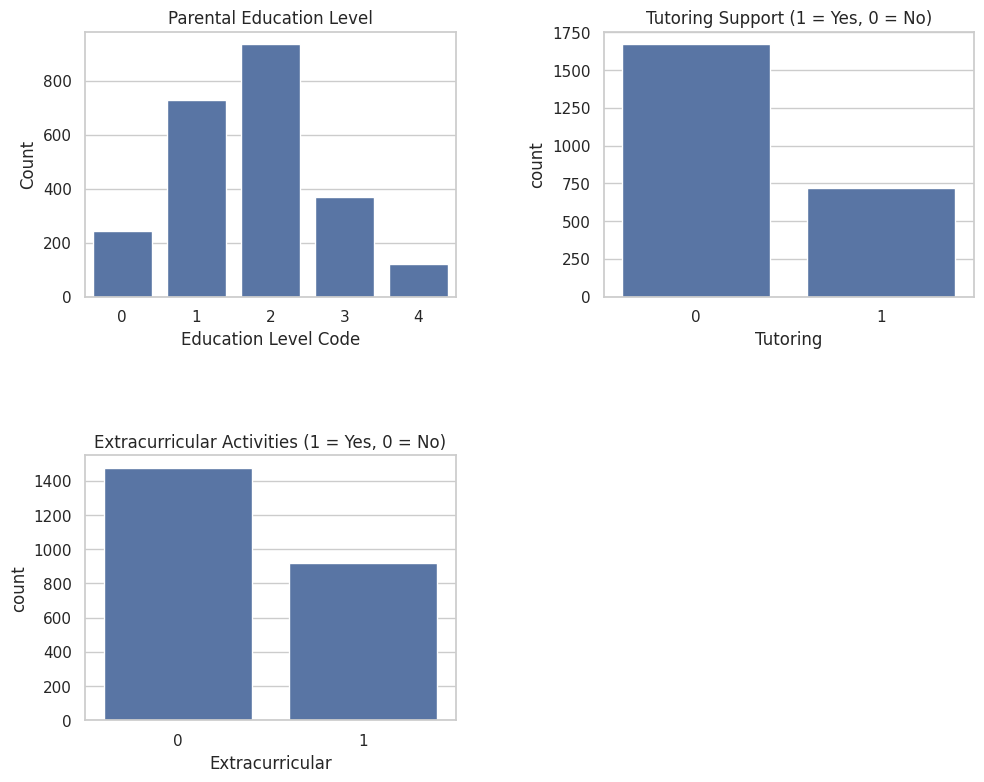

In [13]:
# Map Gender and Ethnicity to readable labels
df['Gender'] = df['Gender'].map({0: 'Female', 1: 'Male'})
df['Ethnicity'] = df['Ethnicity'].map({
    0: 'Group A', 1: 'Group B', 2: 'Group C', 3: 'Group D', 4: 'Group E'
})

# Set style
sns.set(style="whitegrid")

# Plot layout
plt.figure(figsize=(10, 12))

# Parental Education bar plot
plt.subplot(3, 2, 3)
edu_counts = df['ParentalEducation'].value_counts()
sns.barplot(x=edu_counts.index, y=edu_counts.values)
plt.title('Parental Education Level')
plt.xlabel('Education Level Code')
plt.ylabel('Count')

# Tutoring support count plot
plt.subplot(3, 2, 4)
sns.countplot(x='Tutoring', data=df)
plt.title('Tutoring Support (1 = Yes, 0 = No)')

# Extracurricular participation count plot
plt.subplot(3, 2, 5)
sns.countplot(x='Extracurricular', data=df)
plt.title('Extracurricular Activities (1 = Yes, 0 = No)')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# Show plot
plt.show()


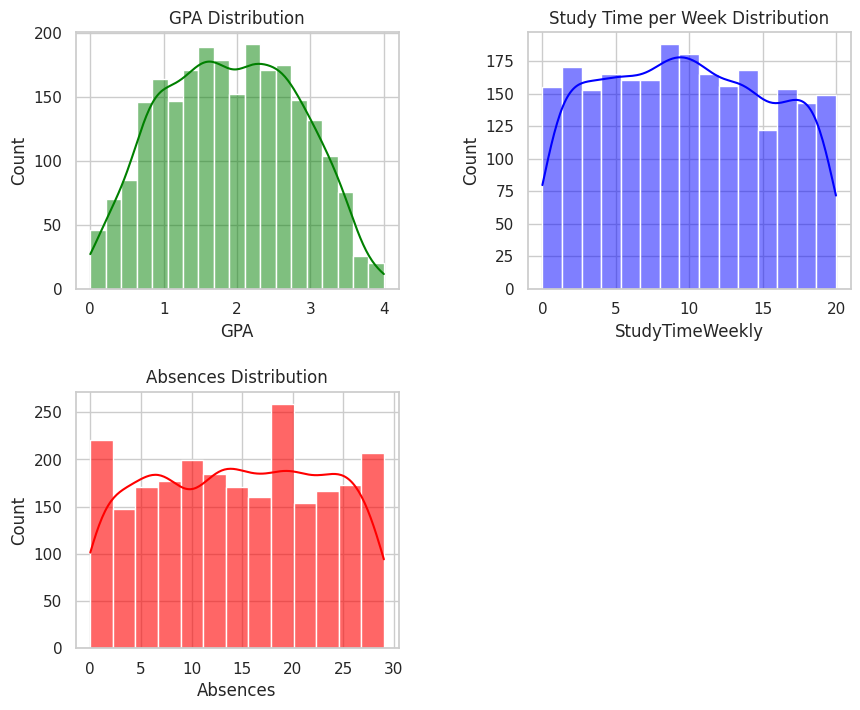

In [14]:
plt.figure(figsize=(10, 8))

# GPA distribution
plt.subplot(2, 2, 1)
sns.histplot(df['GPA'], kde=True, color='green')
plt.title('GPA Distribution')

# Study Time Weekly distribution
plt.subplot(2, 2, 2)
sns.histplot(df['StudyTimeWeekly'], kde=True, color='blue')
plt.title('Study Time per Week Distribution')

# Absences distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Absences'], kde=True, color='red', alpha=0.6)
plt.title('Absences Distribution')

plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.show()

In [15]:
# Mean and Standard Deviation Calculation
gpa_mean = df['GPA'].mean()
gpa_std = df['GPA'].std()

study_mean = df['StudyTimeWeekly'].mean()
study_std = df['StudyTimeWeekly'].std()

absences_mean = df['Absences'].mean()
absences_std = df['Absences'].std()

# Threshold = mean + 3 * std
gpa_threshold = gpa_mean + 3 * gpa_std
study_threshold = study_mean + 3 * study_std
absences_threshold = absences_mean + 3 * absences_std

# Max values from dataset
max_gpa = df['GPA'].max()
max_study = df['StudyTimeWeekly'].max()
max_absences = df['Absences'].max()

# GPA Check
if gpa_threshold > 0 and gpa_threshold < max_gpa:
    print("No outliers in column GPA")
else:
    print(f"There are outliers in column GPA and outliers = {gpa_threshold - max_gpa:.2f}")

# StudyTimeWeekly Check
if study_threshold > 0 and study_threshold < max_study:
    print("No outliers in column StudyTimeWeekly")
else:
    print(f"There are outliers in column StudyTimeWeekly and outliers = {study_threshold - max_study:.2f}")

# Absences Check
if absences_threshold > 0 and absences_threshold < max_absences:
    print("No outliers in column Absences")
else:
    print(f"There are outliers in column Absences and outliers = {absences_threshold - max_absences:.2f}")


There are outliers in column GPA and outliers = 0.65
There are outliers in column StudyTimeWeekly and outliers = 6.75
There are outliers in column Absences and outliers = 10.94


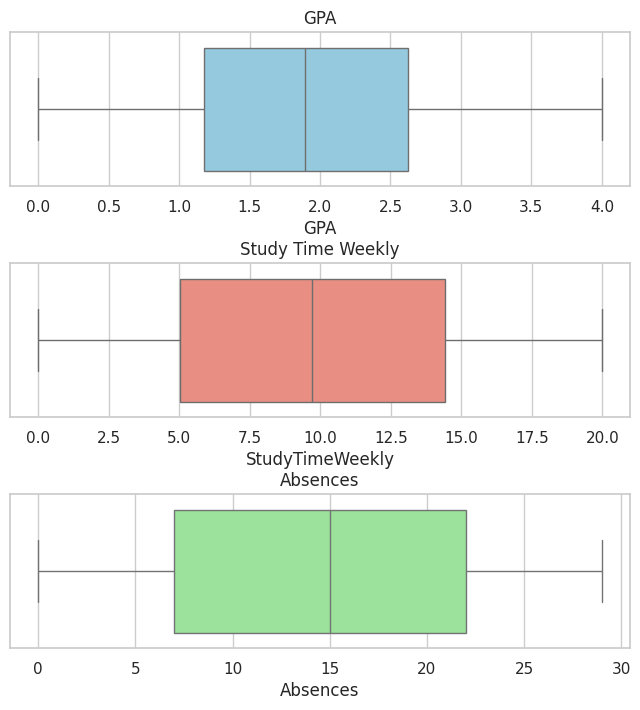

In [16]:
plt.figure(figsize=(8, 8))

# GPA
plt.subplot(3, 1, 1)
sns.boxplot(x=df['GPA'], orient='h', color='skyblue')
plt.title('GPA')

# Study Time Weekly
plt.subplot(3, 1, 2)
sns.boxplot(x=df['StudyTimeWeekly'], orient='h', color='salmon')
plt.title('Study Time Weekly')

# Absences
plt.subplot(3, 1, 3)
sns.boxplot(x=df['Absences'], orient='h', color='lightgreen')
plt.title('Absences')

plt.subplots_adjust(hspace=0.5)
plt.show()


In [17]:
print(df[['Gender', 'GPA']].isnull().sum())      # Check missing values
print(df['GPA'].dtype)                           # Check data type
print(df['Gender'].unique())                     # See unique values in Gender


Gender    0
GPA       0
dtype: int64
float64
['Male' 'Female']


In [22]:
# Handle missing values
df = df.dropna()

# Features & Target
X = df.drop(columns=['GradeClass'])  # Predicting GradeClass
y = df['GradeClass']

# Convert categorical features to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [23]:
# Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.32      0.47        22
         1.0       0.78      0.86      0.82        49
         2.0       0.91      0.86      0.88        85
         3.0       0.88      0.90      0.89        86
         4.0       0.94      0.99      0.96       237

    accuracy                           0.90       479
   macro avg       0.88      0.78      0.80       479
weighted avg       0.90      0.90      0.90       479



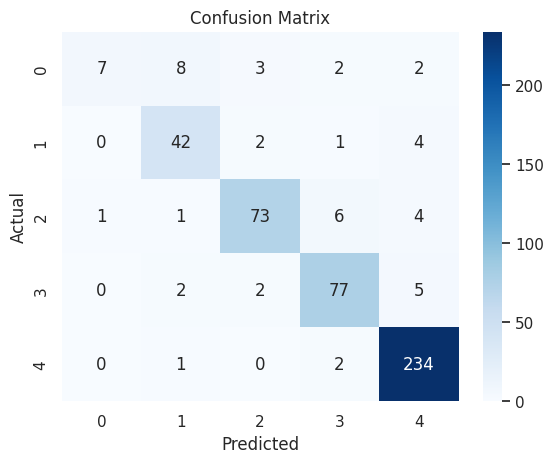

In [25]:
# Predictions and evaluation
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest:
               precision    recall  f1-score   support

         0.0       0.90      0.41      0.56        22
         1.0       0.80      0.90      0.85        49
         2.0       0.94      0.86      0.90        85
         3.0       0.89      0.90      0.89        86
         4.0       0.94      0.99      0.96       237

    accuracy                           0.91       479
   macro avg       0.89      0.81      0.83       479
weighted avg       0.91      0.91      0.91       479



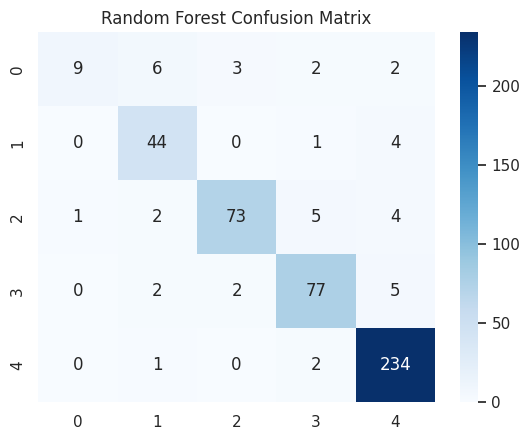

In [26]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

print("Random Forest:\n", classification_report(y_test, y_pred_rfc))

sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()


Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        22
         1.0       0.44      0.49      0.47        49
         2.0       0.60      0.60      0.60        85
         3.0       0.71      0.56      0.62        86
         4.0       0.88      0.98      0.92       237

    accuracy                           0.74       479
   macro avg       0.53      0.53      0.52       479
weighted avg       0.71      0.74      0.72       479



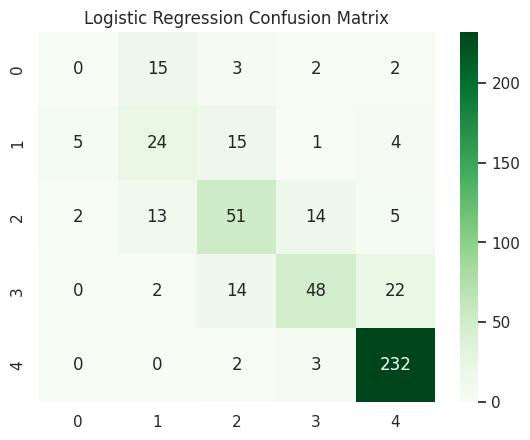

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


=== Confusion Matrix using only 'Age' to predict GradeClass ===


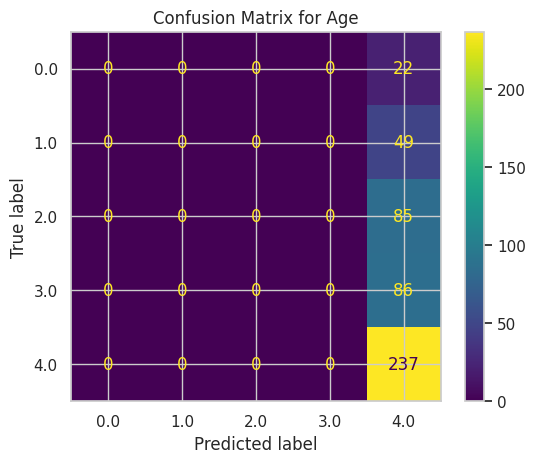


=== Confusion Matrix using only 'ParentalEducation' to predict GradeClass ===


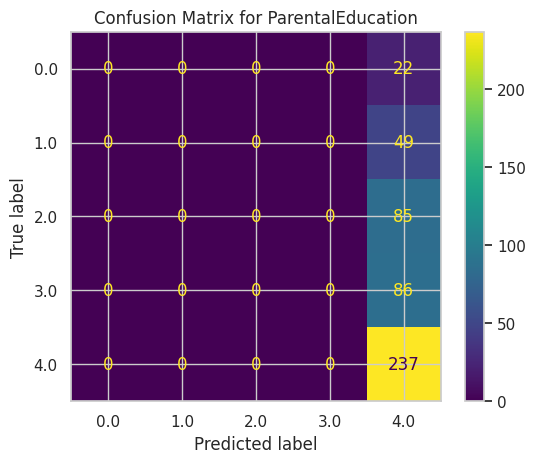


=== Confusion Matrix using only 'StudyTimeWeekly' to predict GradeClass ===


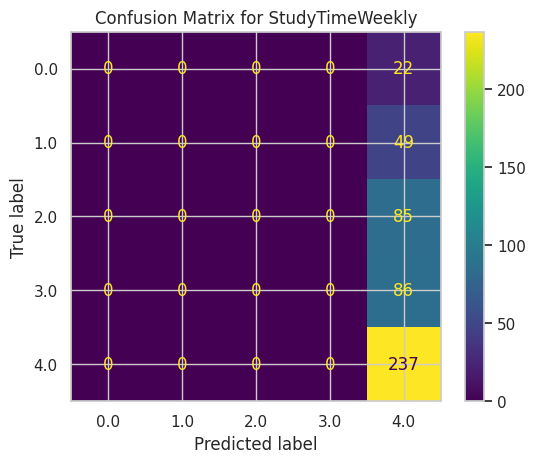


=== Confusion Matrix using only 'Absences' to predict GradeClass ===


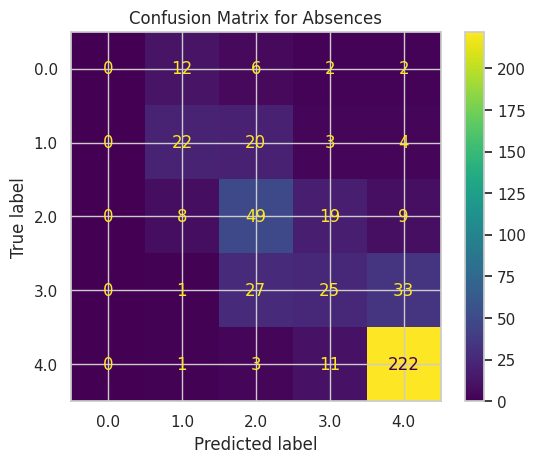


=== Confusion Matrix using only 'Tutoring' to predict GradeClass ===


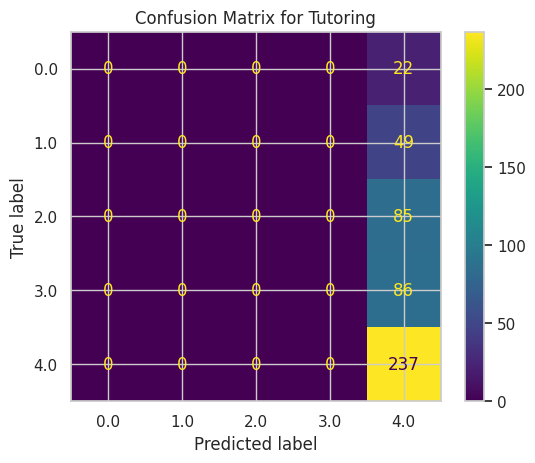


=== Confusion Matrix using only 'ParentalSupport' to predict GradeClass ===


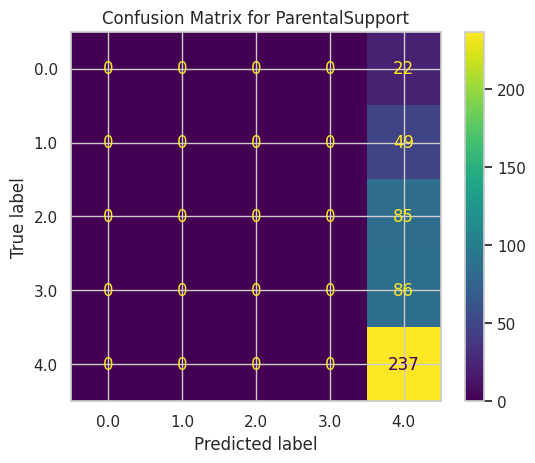


=== Confusion Matrix using only 'Extracurricular' to predict GradeClass ===


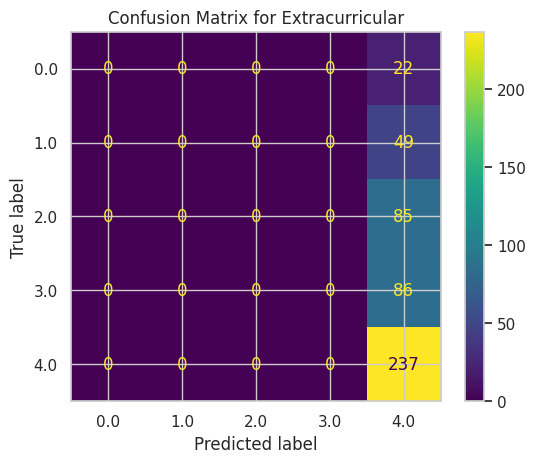


=== Confusion Matrix using only 'Sports' to predict GradeClass ===


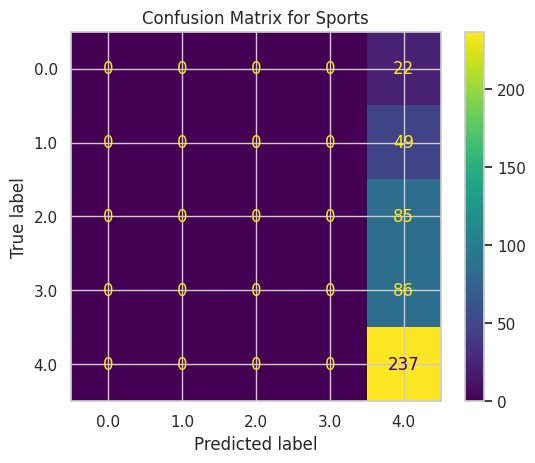


=== Confusion Matrix using only 'Music' to predict GradeClass ===


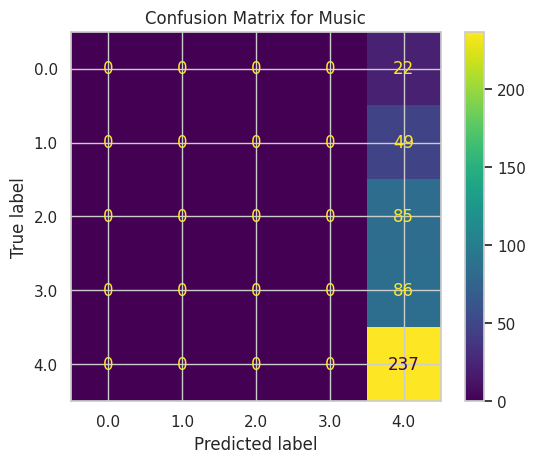


=== Confusion Matrix using only 'Volunteering' to predict GradeClass ===


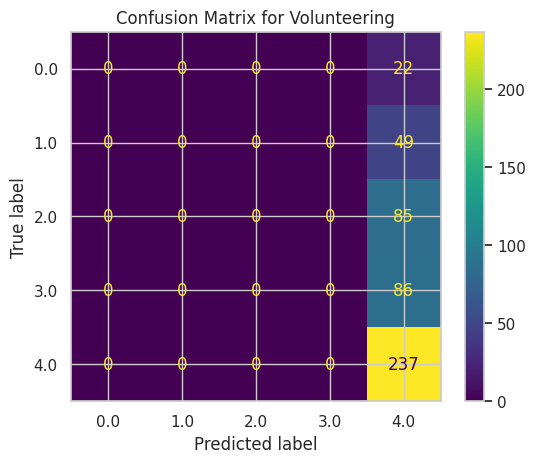


=== Confusion Matrix using only 'GradeClass' to predict GradeClass ===


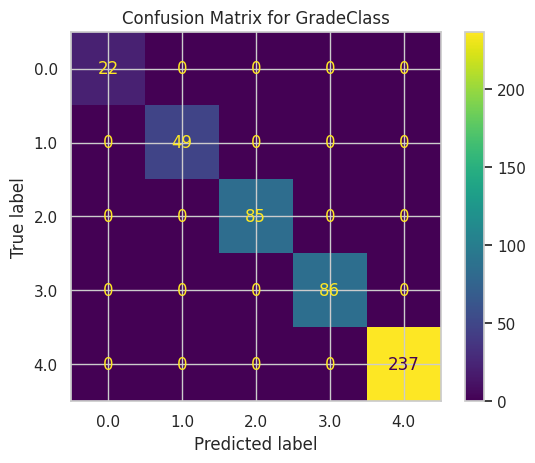

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# Identify numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['GPA']).columns

for feature in numeric_features:
    print(f"\n=== Confusion Matrix using only '{feature}' to predict GradeClass ===")

    # Reshape feature to 2D array as required by sklearn
    X_feature = df[[feature]].values
    y = df['GradeClass']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=42)

    # Train logistic regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Generate and display confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='viridis')
    plt.title(f'Confusion Matrix for {feature}')
    plt.show()


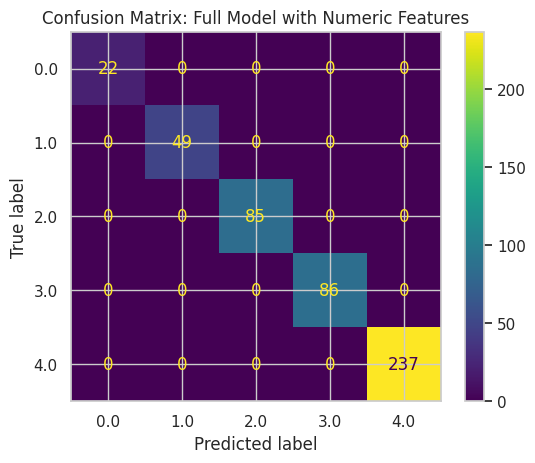

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='viridis')
plt.title('Confusion Matrix: Full Model with Numeric Features')
plt.show()


SVM:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        22
         1.0       1.00      1.00      1.00        49
         2.0       1.00      1.00      1.00        85
         3.0       1.00      1.00      1.00        86
         4.0       1.00      1.00      1.00       237

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



<Axes: >

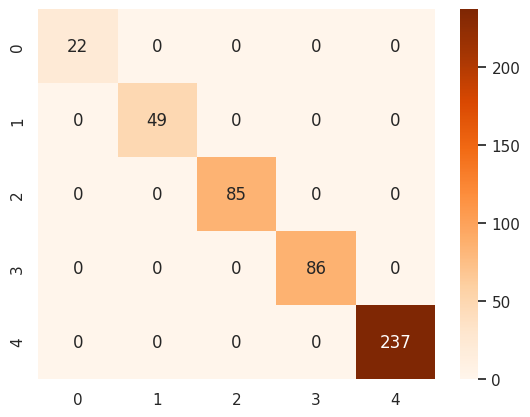

In [30]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM:\n", classification_report(y_test, y_pred_svm))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Oranges')
